In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("../graphs", exist_ok=True)

# choose integration function: prefer numpy.trapezoid, fallback to numpy.trapz
if hasattr(np, "trapezoid"):
    integrate = np.trapezoid
else:
    integrate = np.trapz

noises = [0] + [round(i*0.01, 2) for i in range(1, 11)]

summary_rows = []

for test in ['testAB', 'testAG', 'test']:
    for noise in noises:
        base_dir = f"../results/noise{noise}"
        
        runs = [f"rand{i}" for i in range(100)]
        
        dfs_qbc = []
        dfs_random = []
        
        for run in runs:
            path = os.path.join(base_dir, run)
            if not os.path.exists(path):
                continue
            for file in os.listdir(path):
                if file.startswith("roc_aucs_qbc"):
                    df = pd.read_csv(os.path.join(path, file), sep="\t")
                    dfs_qbc.append(df)
                elif file.startswith("roc_aucs_random"):
                    df = pd.read_csv(os.path.join(path, file), sep="\t")
                    dfs_random.append(df)
        
        if not dfs_qbc or not dfs_random:
            continue
        
        df_qbc_all = pd.concat(dfs_qbc, ignore_index=True)
        df_random_all = pd.concat(dfs_random, ignore_index=True)
        
        qbc_mean = df_qbc_all.groupby("ags_number")[f"roc_aucs_{test}"].mean()
        random_mean = df_random_all.groupby("ags_number")[f"roc_aucs_{test}"].mean()

        qbc_mean.index = pd.to_numeric(qbc_mean.index, errors='coerce')
        random_mean.index = pd.to_numeric(random_mean.index, errors='coerce')
        qbc_mean = qbc_mean.dropna().sort_index()
        random_mean = random_mean.dropna().sort_index()

        common_index = qbc_mean.index.intersection(random_mean.index).sort_values()
        if common_index.empty:
            print(f"Skipped noise={noise}, test={test}: no common ags_number between QBC and Random.")
            continue

        y_qbc = qbc_mean.loc[common_index].values
        y_random = random_mean.loc[common_index].values
        x = common_index.values.astype(float)

        # compute area under curve using chosen integrator (trapezoid / trapz)
        auc_qbc = integrate(y_qbc, x)
        auc_random = integrate(y_random, x)

        x_range = x.max() - x.min()
        if x_range > 0:
            auc_qbc_norm = auc_qbc / x_range
            auc_random_norm = auc_random / x_range
        else:
            auc_qbc_norm = np.nan
            auc_random_norm = np.nan

        diff = auc_qbc - auc_random
        diff_norm = auc_qbc_norm - auc_random_norm

        # print(f"noise={noise}, test={test}: AUC_QBC={auc_qbc:.6f}, AUC_Random={auc_random:.6f}, diff={diff:.6f}")
        # print(f"  normalized: AUC_QBC_norm={auc_qbc_norm:.6f}, AUC_Random_norm={auc_random_norm:.6f}, diff_norm={diff_norm:.6f}")

        summary_rows.append({
            "test": test,
            "noise": noise,
            "auc_qbc": auc_qbc,
            "auc_random": auc_random,
            "auc_diff": diff,
            "auc_qbc_norm": auc_qbc_norm,
            "auc_random_norm": auc_random_norm,
            "auc_diff_norm": diff_norm,
            "x_min": x.min(),
            "x_max": x.max(),
        })

if summary_rows:
    df_summary = pd.DataFrame(summary_rows)
    out_path = "../graphs/auc_summary.csv"
    df_summary.to_csv(out_path, index=False)
    print(f"\nSaved AUC summary to {out_path}")
else:
    print("No AUCs were computed (no data found).")



Saved AUC summary to ../graphs/auc_summary.csv


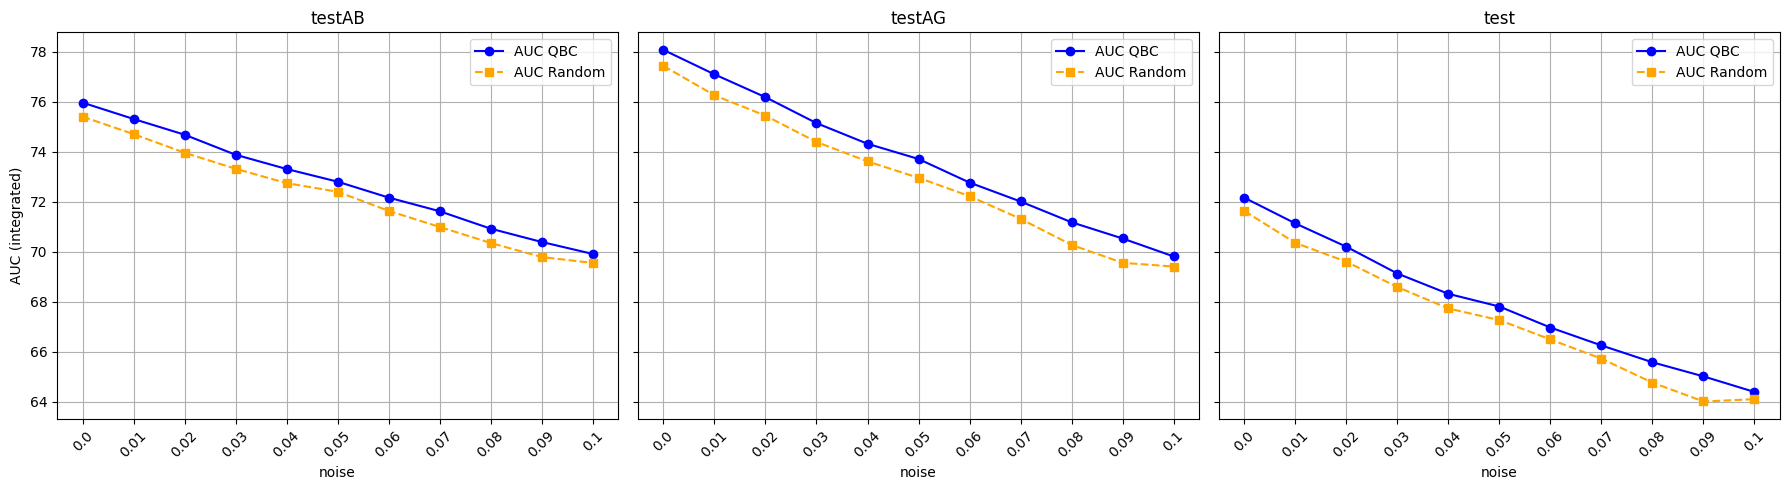

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Paths
in_path = "../graphs/auc_summary.csv"
out_dir = "../graphs"
os.makedirs(out_dir, exist_ok=True)
out_png = os.path.join(out_dir, "auc_summary_plot.png")

# Read summary
df = pd.read_csv(in_path)

# Ensure numeric noise
df['noise'] = pd.to_numeric(df['noise'], errors='coerce')
df = df.dropna(subset=['noise']).copy()

tests = ['testAB', 'testAG', 'test']

# Create figure with 3 subplots in one row
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, test in zip(axes, tests):
    df_t = df[df['test'] == test].sort_values('noise')
    if df_t.empty:
        ax.text(0.5, 0.5, "no data", ha='center', va='center', fontsize=12)
        ax.set_title(test)
        ax.set_xlabel("noise")
        continue

    x = df_t['noise'].values
    y_qbc = df_t['auc_qbc'].values
    y_random = df_t['auc_random'].values

    # Plot AUC curves with specified colors: blue for QBC, orange for Random
    ax.plot(x, y_qbc, marker='o', linestyle='-', label='AUC QBC', color='blue')
    ax.plot(x, y_random, marker='s', linestyle='--', label='AUC Random', color='orange')

    ax.set_title(test)
    ax.set_xlabel("noise")
    ax.grid(True)
    ax.legend()
    # optionally set x ticks to show all noise values
    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in x], rotation=45)

# y label on the leftmost subplot
axes[0].set_ylabel("AUC (integrated)")

plt.tight_layout()
# plt.savefig(out_png, dpi=150)
plt.show()
